In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
# Specifically ignore Deprecation Warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Ignore future warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-personality-analysis/marketing_campaign.csv


# Loading and Understanding Data

In [2]:
data = pd.read_csv('/kaggle/input/customer-personality-analysis/marketing_campaign.csv',sep='\t')
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
data.shape

(2240, 29)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [6]:
data.describe(include='object')

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


In [7]:
data['ID'].duplicated().sum() 

0

Each customer has exactly 1 transaction

In [8]:
data.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

# Data Exploration and Feature Engineering

In [9]:
#Replace the NaNs in Income with its mean value
data['Income'] = data['Income'].fillna(data['Income'].mean()) 
data['Income'].isnull().sum()

0

In [10]:
#Remove these variable as they have constant values and will not contribute in the anlysis
data.drop(['Z_Revenue','Z_CostContact'],axis=1,inplace=True) 

In [11]:
#counting the values per category in Marital_Status
data['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [12]:
#Reducing the numbet of categories in Marital Status
data['Marital_Status']=data['Marital_Status'].replace({'Alone':'Single','YOLO':'Single','Absurd':'Single'})

In [13]:
#counting the values per category in Marital_Status
data['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [14]:
#Reducing the numbet of categories in Education
data['Education'] = data['Education'].replace({'Basic':'UG','2n Cycle':'UG'})

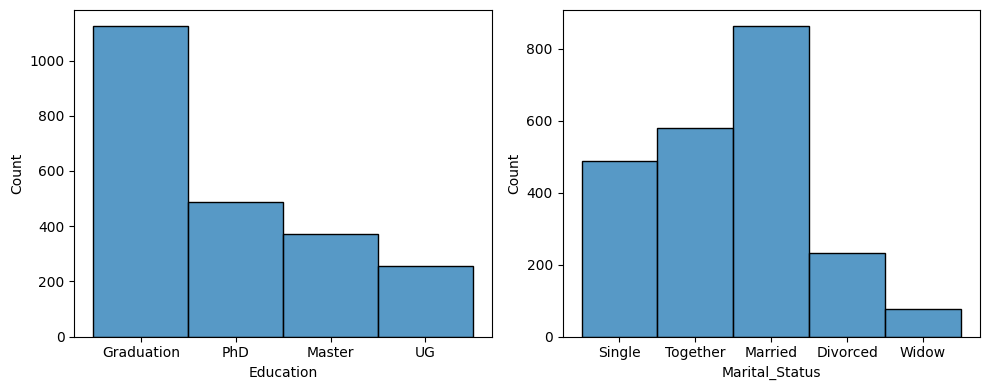

In [15]:
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(10,4))

sns.histplot(data['Education'],ax=axes[0])
sns.histplot(data['Marital_Status'],ax=axes[1])

plt.tight_layout()
plt.show()

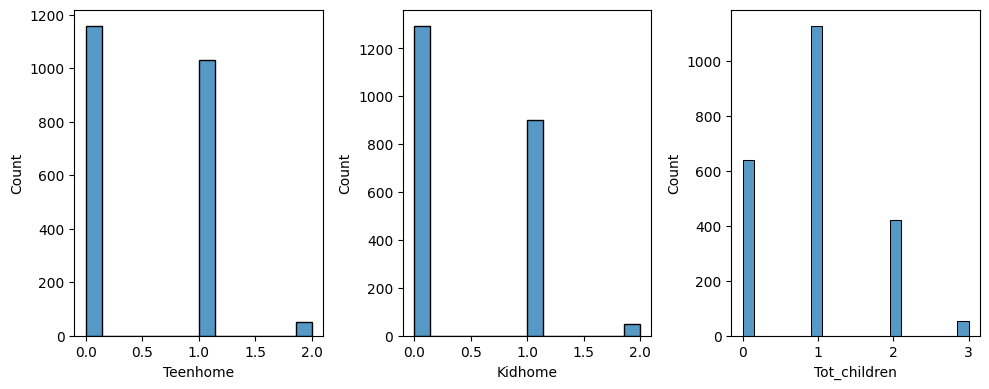

In [16]:
#Create a new variable to calculate total no. of children 
data['Tot_children'] = data['Teenhome']+data['Kidhome']

fig, axes = plt.subplots(nrows=1, ncols=3,figsize=(10,4))

sns.histplot(data['Teenhome'],ax=axes[0])
sns.histplot(data['Kidhome'],ax=axes[1])
sns.histplot(data['Tot_children'],ax=axes[2])
plt.tight_layout()
plt.show()

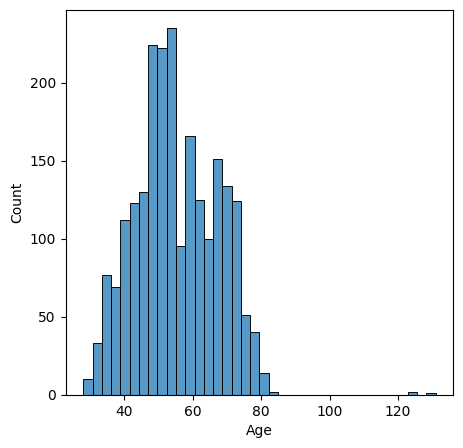

In [17]:
#Find out the age of customers
data['Age'] = 2024-data['Year_Birth']
plt.figure(figsize=(5,5))
sns.histplot(data['Age'])
plt.show()

In [18]:
#removing outliers from age - clipping the age at 81
data['Age'] = data['Age'].clip(upper=81)

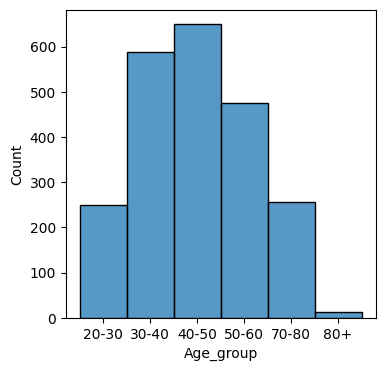

In [19]:
#Create a new variable 'Age_group' to form groups of customers by age
bins=[30,40,50,60,70,80,90]
labels = ['20-30','30-40','40-50','50-60','70-80','80+']

data['Age_group'] = pd.cut(data['Age'],bins=bins,labels=labels)
plt.figure(figsize=(4,4))
sns.histplot(data['Age_group'])
plt.show()

In [20]:
#create new columns which calculate the total expenses, accepted coupons and place of purchase
data['Tot_Expenses'] = data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] + data['MntFishProducts'] + data['MntSweetProducts'] + data['MntGoldProds']
data['Tot_AcceptedCmp'] = data['AcceptedCmp1'] + data['AcceptedCmp2'] + data['AcceptedCmp3'] + data['AcceptedCmp4'] + data['AcceptedCmp5'] + data['Response']
data['Tot_Purchases'] = data['NumWebPurchases'] + data['NumCatalogPurchases'] + data['NumStorePurchases'] + data['NumDealsPurchases']


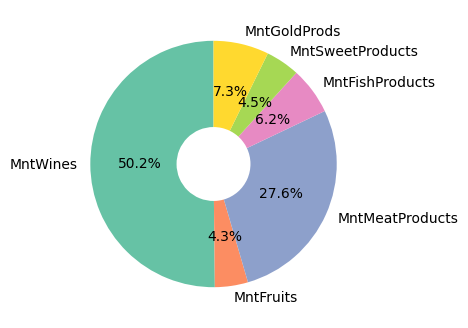

In [21]:
#Distribution of Products
products = data.loc[:,['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']]
products_tot = products.sum()
#products_tot

plt.figure(figsize=(4,4))
plt.pie(products_tot,labels=products_tot.index,wedgeprops={'width': 0.7},textprops={'fontsize': 10},autopct='%1.1f%%',startangle=90,colors=sns.color_palette('Set2'))
plt.show()

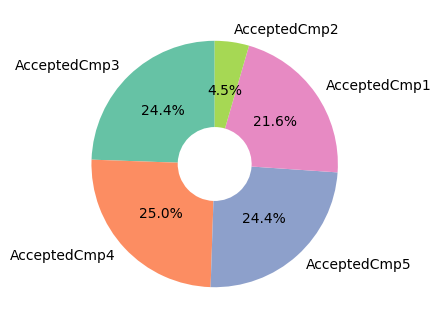

In [22]:
#distribution of Promotion Acceptance
promotion = data.loc[:,['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2']]
promotion_tot = promotion.sum()
#products_tot

plt.figure(figsize=(4,4))
plt.pie(promotion_tot,labels=promotion_tot.index,wedgeprops={'width': 0.7},textprops={'fontsize': 10},
        autopct='%1.1f%%',startangle=90,colors=sns.color_palette('Set2'))
plt.show()

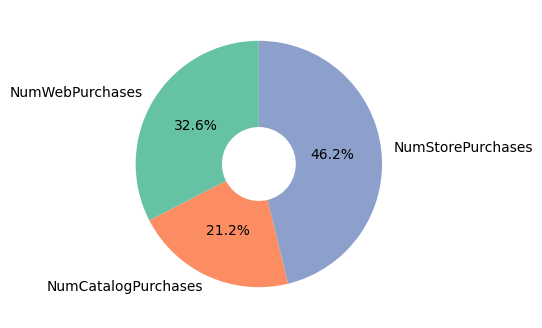

In [23]:
#distribution of Places
places = data.loc[:,[ 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases']]
places_tot = places.sum()

plt.figure(figsize=(4,4))
plt.pie(places_tot,labels=places_tot.index,wedgeprops={'width': 0.7},textprops={'fontsize': 10},
        autopct='%1.1f%%',startangle=90,colors=sns.color_palette('Set2'))
plt.show()

# Bivariate Analysis

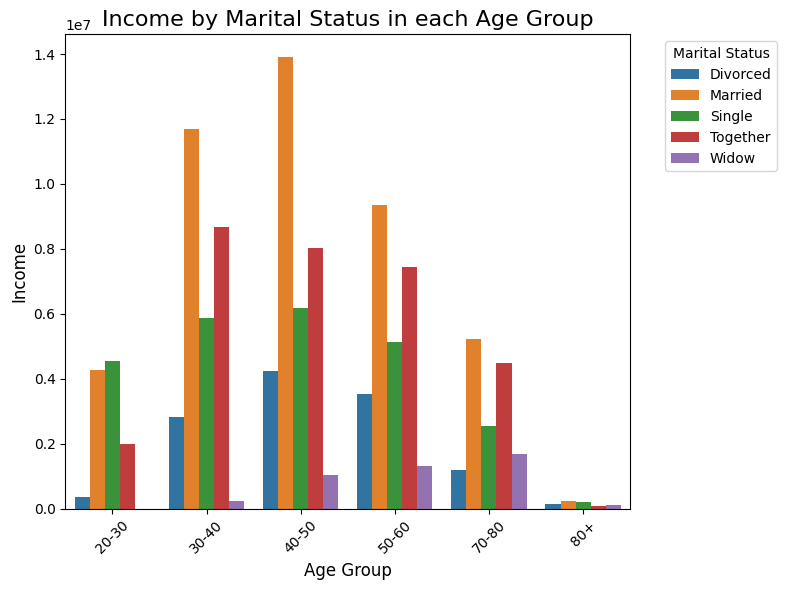

In [24]:

g1 = data.groupby(['Age_group','Marital_Status'])['Income'].sum().reset_index().sort_values(by='Age_group')

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=g1,x='Age_group',y='Income',hue='Marital_Status')
ax.set_title('Income by Marital Status in each Age Group', fontsize=16)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Income', fontsize=12)
ax.legend(title='Marital Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**: 'Married' and 'Together' customers have the maximum income in all age groups - probably because it is the sum of two salaries

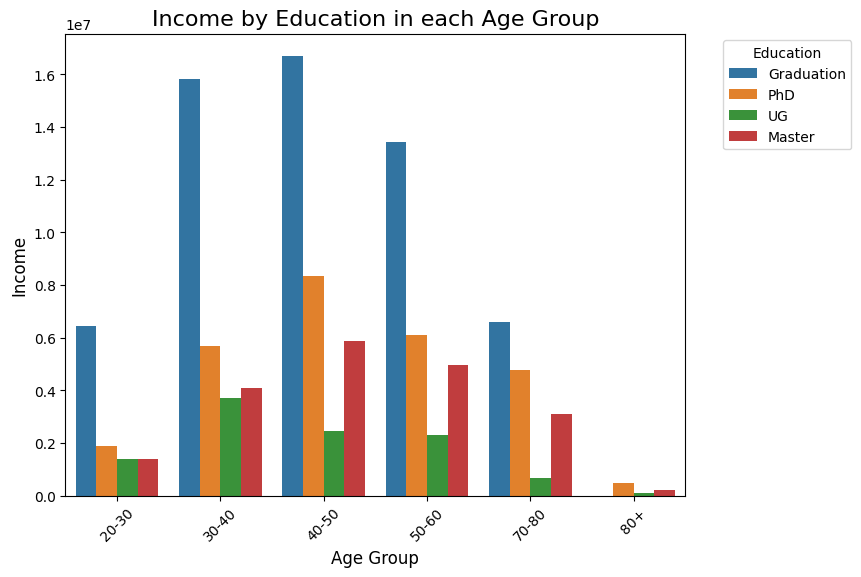

In [25]:

g2=data.groupby(['Education','Age_group'])['Income'].sum().reset_index().sort_values(by='Age_group')

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=g2,x='Age_group',y='Income',hue='Education')
ax.set_title('Income by Education in each Age Group', fontsize=16)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Income', fontsize=12)
ax.legend(title='Education', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

**Observation**: Graduates earn the most on all age groups followed by PhD and Masters

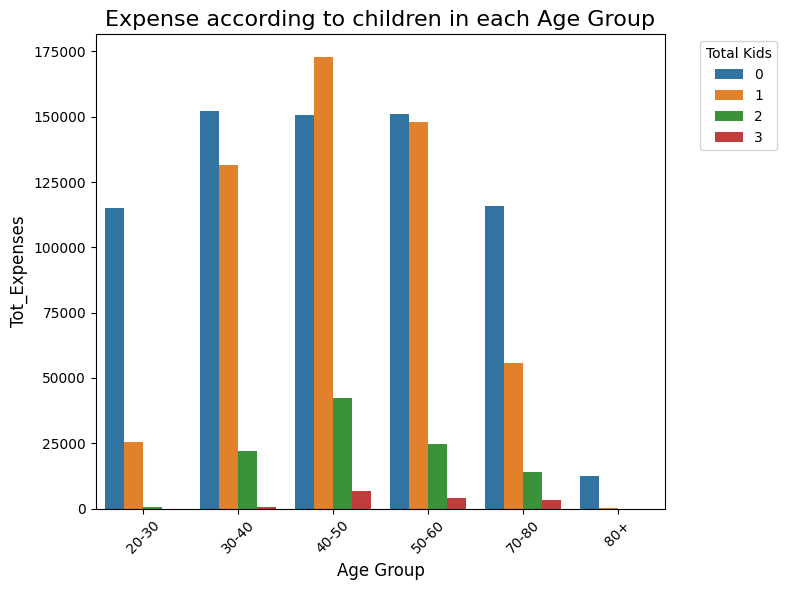

In [26]:

g3=data.groupby(['Tot_children','Age_group'])['Tot_Expenses'].sum().reset_index().sort_values(by='Age_group')

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=g3,x='Age_group',y='Tot_Expenses',hue='Tot_children')
ax.set_title('Expense according to children in each Age Group', fontsize=16)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Tot_Expenses', fontsize=12)
ax.legend(title='Total Kids', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**: Almost in all age groups customers with 0 or 1 kids spend significantly more as compared to customers with 2 or 3 kids

**Spending Distributions by Marital Status, Age Group and Education**

In [27]:
#Function to create stacked barchart
def stackbar(data):
    categories = data.index
    values = data.values
    columns=data.columns
    
    fig, ax = plt.subplots(figsize=(8,6))
    cum_sum=np.zeros(len(categories))

    for i,columns in enumerate(columns):
        plot = ax.bar(categories, values[:,i],bottom=cum_sum,label=columns)
        cum_sum+=values[:,i]
    return (plot)

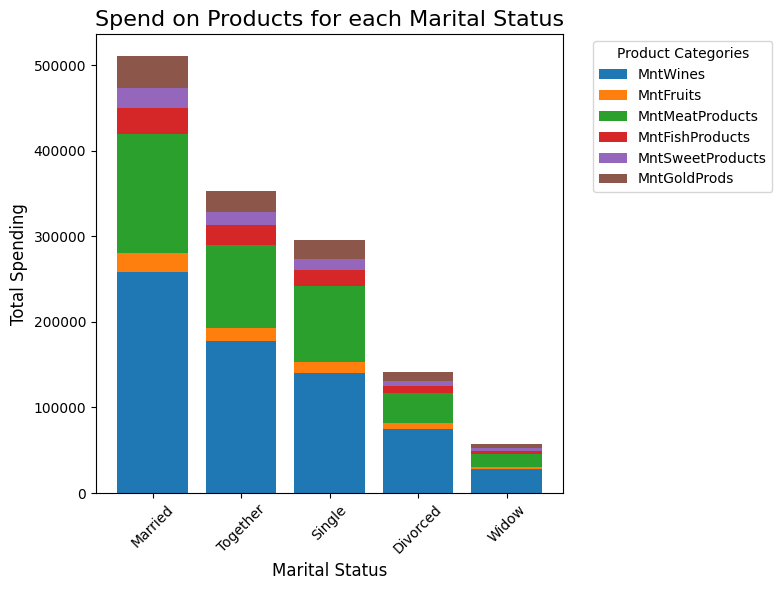

In [28]:

group1 = data.groupby('Marital_Status').agg({'MntWines':'sum', 'MntFruits':'sum',
       'MntMeatProducts':'sum', 'MntFishProducts':'sum', 'MntSweetProducts':'sum',
       'MntGoldProds':'sum'}).sort_values(by='MntWines',ascending=False)

stackbar(group1)
# Add labels, title, and legend
plt.title('Spend on Products for each Marital Status', fontsize=16)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)
plt.legend(title='Product Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**: 'Married' and 'Together' customers are the biggest spenders - spending maximum on Wine and Meat products



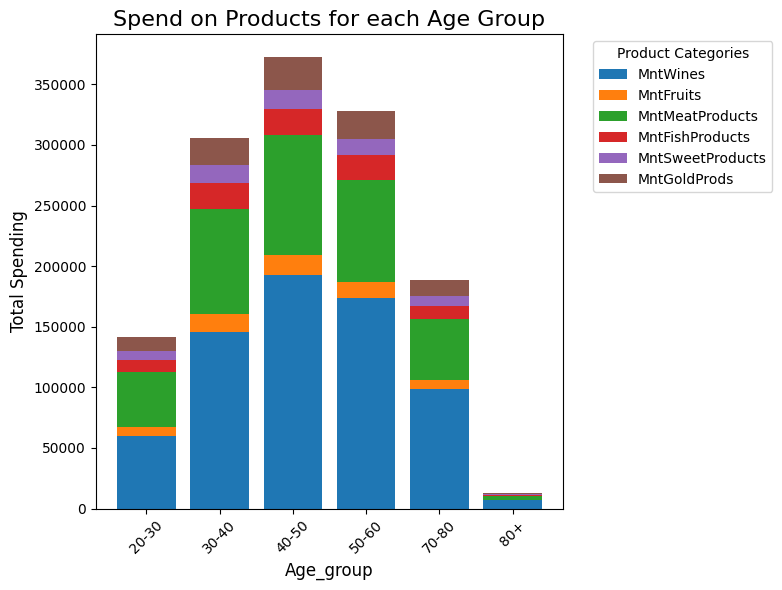

In [29]:

group2 = data.groupby('Age_group').agg({'MntWines':'sum', 'MntFruits':'sum',
       'MntMeatProducts':'sum', 'MntFishProducts':'sum', 'MntSweetProducts':'sum',
       'MntGoldProds':'sum'}).sort_values(by='Age_group')

stackbar(group2)
# Add labels, title, and legend
plt.title('Spend on Products for each Age Group', fontsize=16)
plt.xlabel('Age_group', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)
plt.legend(title='Product Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**: Customers in the age group of 30-60 are the biggest buyer and and spend mostly on Wine and Meat

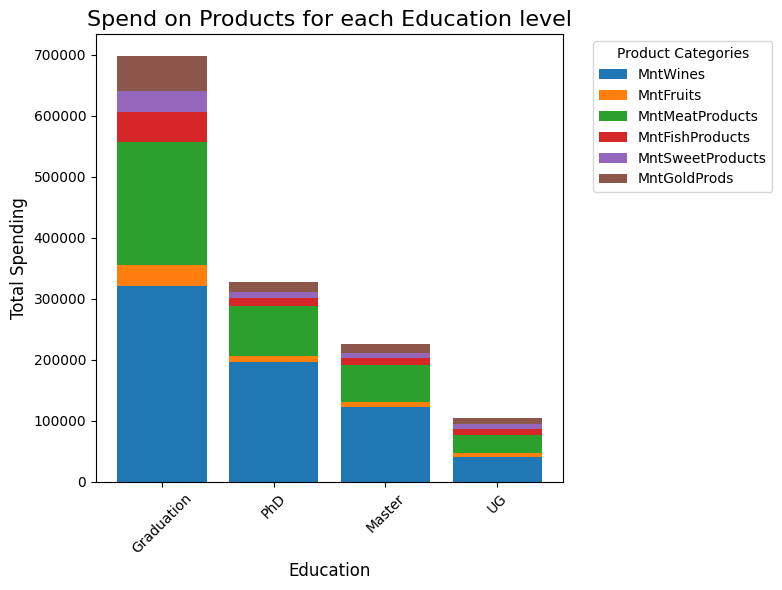

In [30]:

group3 = data.groupby('Education').agg({'MntWines':'sum', 'MntFruits':'sum','MntMeatProducts':'sum', 'MntFishProducts':'sum', 'MntSweetProducts':'sum',
       'MntGoldProds':'sum'}).sort_values(by='MntWines',ascending=False)

stackbar(group3)
# Add labels, title, and legend
plt.title('Spend on Products for each Education level', fontsize=16)
plt.xlabel('Education', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)
plt.legend(title='Product Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation**: Graduates are the biggest buyers of all, this also correlates with the Income chart where the Graduate customers also earn the maximum.

****Promotion Acceptance Distribution by Marital Status, Age Group and Education****

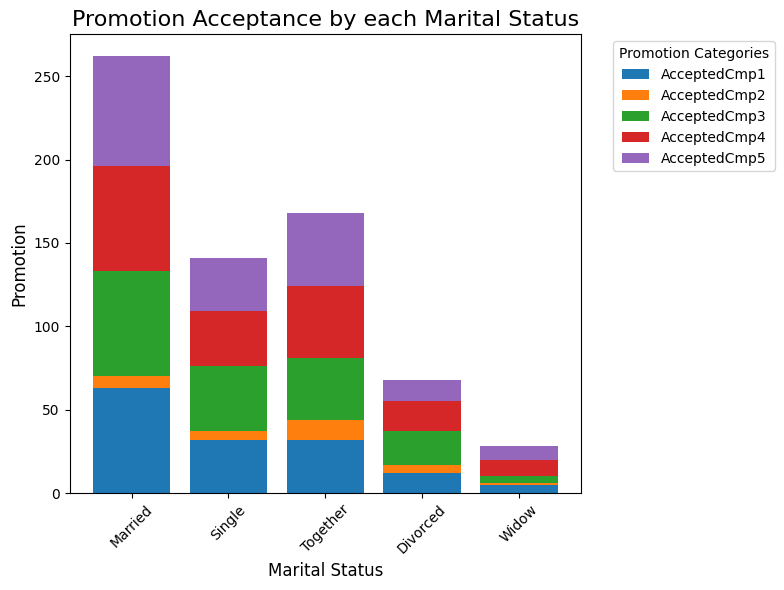

In [31]:

group4 = data.groupby(['Marital_Status']).agg({'AcceptedCmp1':'sum','AcceptedCmp2':'sum','AcceptedCmp3':'sum','AcceptedCmp4': 'sum',
    'AcceptedCmp5':'sum', }).sort_values(by='AcceptedCmp1',ascending=False)


stackbar(group4)
# Add labels, title, and legend
plt.title('Promotion Acceptance by each Marital Status', fontsize=16)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Promotion', fontsize=12)
plt.legend(title='Promotion Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Ovservation**: Even though the 'Married' and 'Together' customers are more likely to accept promotions - there is a significantly low number of customers who accepted the offer in the 2nd campaign

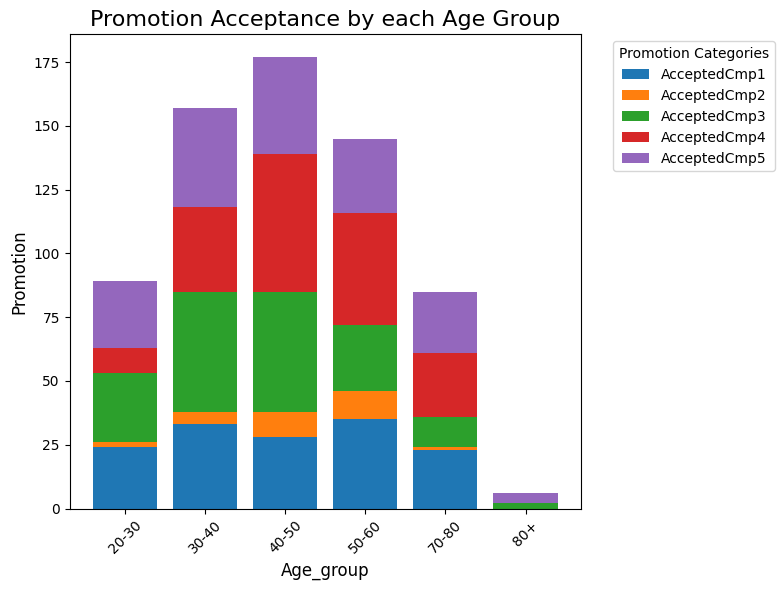

In [32]:

group5 = data.groupby(['Age_group']).agg({'AcceptedCmp1':'sum','AcceptedCmp2':'sum','AcceptedCmp3':'sum','AcceptedCmp4': 'sum',
    'AcceptedCmp5':'sum', }).sort_values(by='Age_group')

stackbar(group5)
# Add labels, title, and legend
plt.title('Promotion Acceptance by each Age Group', fontsize=16)
plt.xlabel('Age_group', fontsize=12)
plt.ylabel('Promotion', fontsize=12)
plt.legend(title='Promotion Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**: Customers in age group of 30-60 are more likely to accept the offer in 3rd, 4th or 5th attempt.

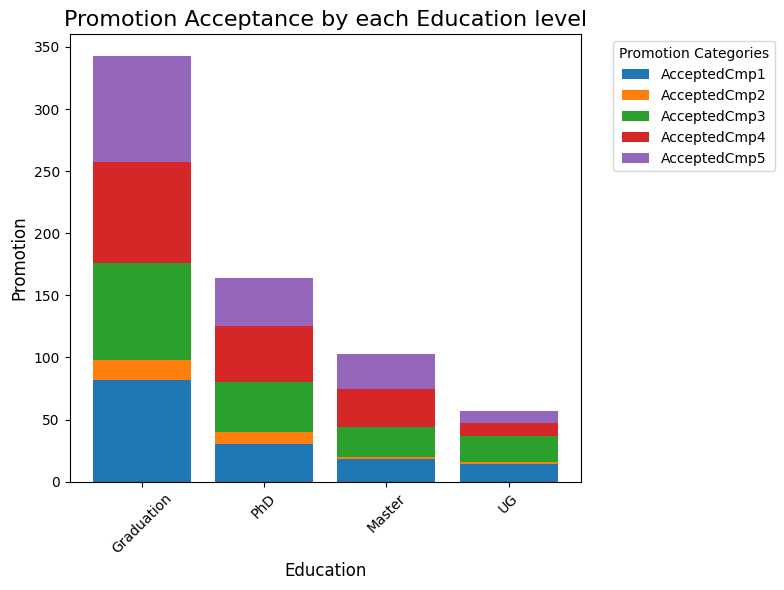

In [33]:

group6 = data.groupby(['Education']).agg({'AcceptedCmp1':'sum','AcceptedCmp2':'sum','AcceptedCmp3':'sum','AcceptedCmp4': 'sum',
    'AcceptedCmp5':'sum',}).sort_values(by='AcceptedCmp1',ascending=False)

stackbar(group6)
# Add labels, title, and legend
plt.title('Promotion Acceptance by each Education level', fontsize=16)
plt.xlabel('Education', fontsize=12)
plt.ylabel('Promotion', fontsize=12)
plt.legend(title='Promotion Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**: Graduates are more likey to accept a promotion 

**Purchase Place Distribution by Marital Status, Age Group and Education**

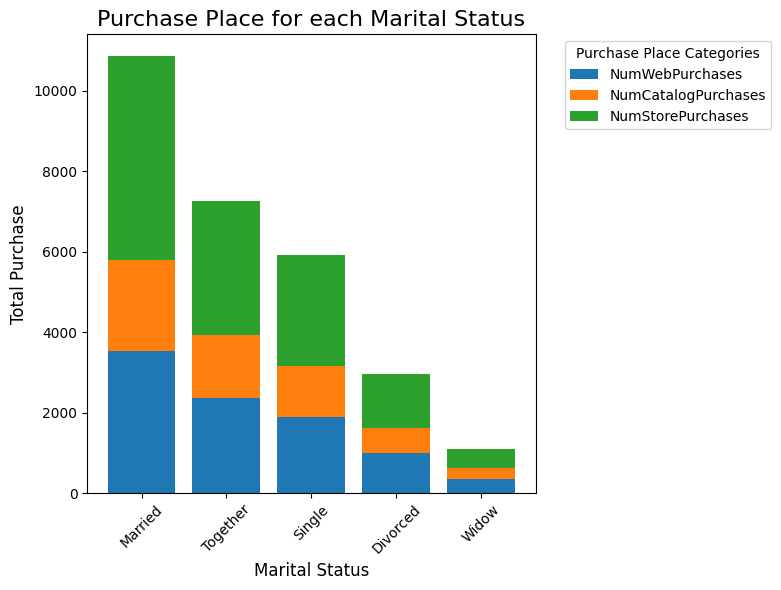

In [34]:

group7 = data.groupby(['Marital_Status']).agg({'NumWebPurchases':'sum','NumCatalogPurchases':'sum','NumStorePurchases': 'sum',
}).sort_values(by='NumStorePurchases',ascending=False)

stackbar(group7)
# Add labels, title, and legend
plt.title('Purchase Place for each Marital Status', fontsize=16)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Total Purchase', fontsize=12)
plt.legend(title='Purchase Place Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Obseravtions**: There is a clear affinity among the customers to shop from Stores follwed by a liking for Web Purchases

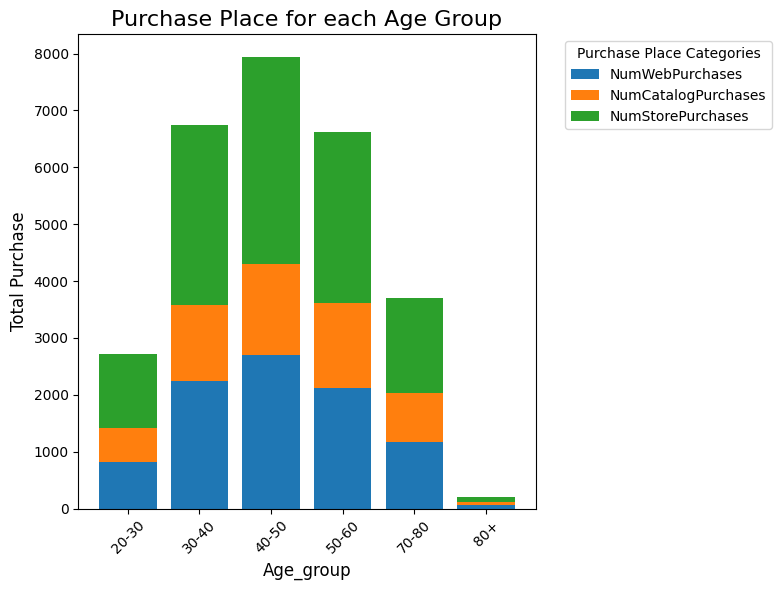

In [35]:

group8 = data.groupby(['Age_group']).agg({'NumWebPurchases':'sum','NumCatalogPurchases':'sum','NumStorePurchases': 'sum',
}).sort_values(by='Age_group')

stackbar(group8)
# Add labels, title, and legend
plt.title('Purchase Place for each Age Group', fontsize=16)
plt.xlabel('Age_group', fontsize=12)
plt.ylabel('Total Purchase', fontsize=12)
plt.legend(title='Purchase Place Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observations**: here too the maximum purchases are made from Stores or through Web

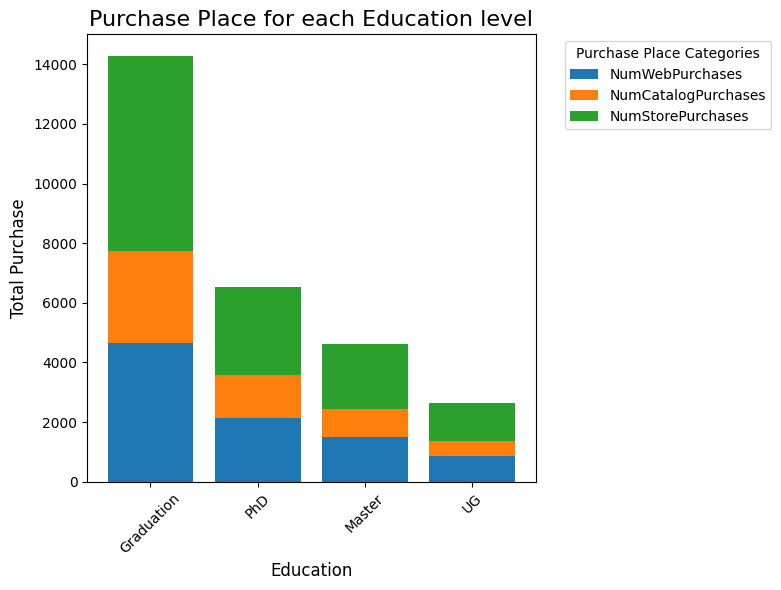

In [36]:

group9 = data.groupby(['Education']).agg({'NumWebPurchases':'sum','NumCatalogPurchases':'sum','NumStorePurchases': 'sum'
                                    }).sort_values(by='NumStorePurchases',ascending=False)

stackbar(group9)
# Add labels, title, and legend
plt.title('Purchase Place for each Education level', fontsize=16)
plt.xlabel('Education', fontsize=12)
plt.ylabel('Total Purchase', fontsize=12)
plt.legend(title='Purchase Place Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation**: Store and Web Purchases are the clear mode of preference for all customers

# EDA Conclusion: Product Recomendations based on Observations

📊 This EDA has given us key insights into customer behaviours. It gave us a fair idea of how a customer's age, income, education and total kids can impact their shopping choices. 

👥 This information can be leveraged in curating bespoke offers for a certain segment of customers.

**eg. A customer who's** **'Married' **and in the age bracket of **'40-50' **will be more likely to buy** 'Wines or Meat Products'** **thorugh a**** 'discout', **from a **'Store or Website'.******


🙋🏻‍♀️ **Note**: At this point we can also create specific Customer Personas reaching out to them with specific marketing strategies.

**eg. A Customer Persona can be:  Single--Graduate--(Age:20-30)**




# Data Preprocessing

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [38]:
df = data.copy()
df = df.drop(['Dt_Customer','Age_group'],axis=1)

In [39]:
#Converting Categorical variables into numrerical
LE = LabelEncoder()
for i in df:
    if df[i].dtype=='object':
        df[i] = LE.fit_transform(df[i])

In [40]:
#Scale Values
SS = StandardScaler()
scaled_data = pd.DataFrame(SS.fit_transform(df.values),index=df.index,columns=df.columns)
scaled_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Tot_children,Age,Tot_Expenses,Tot_AcceptedCmp,Tot_Purchases
0,-0.020999,-0.985345,-0.869930,0.249890,0.235327,-0.825218,-0.929894,0.307039,0.983781,1.551577,...,-0.28014,-0.262111,-0.11651,-0.097282,2.388846,-1.264505,1.012332,1.679417,0.621248,1.320826
1,-1.053058,-1.235733,-0.869930,0.249890,-0.235826,1.032559,0.906934,-0.383664,-0.870479,-0.636301,...,-0.28014,-0.262111,-0.11651,-0.097282,-0.418612,1.396361,1.268204,-0.961275,-0.501912,-1.154596
2,-0.447070,-0.317643,-0.869930,1.192234,0.773633,-0.825218,-0.929894,-0.798086,0.362723,0.570804,...,-0.28014,-0.262111,-0.11651,-0.097282,-0.418612,-1.264505,0.330007,0.282673,-0.501912,0.799685
3,0.181716,1.268149,-0.869930,1.192234,-1.022732,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,...,-0.28014,-0.262111,-0.11651,-0.097282,-0.418612,0.065928,-1.290517,-0.918094,-0.501912,-0.894025
4,-0.082614,1.017761,0.974502,-0.692455,0.241519,1.032559,-0.929894,1.550305,-0.389085,0.419916,...,-0.28014,-0.262111,-0.11651,-0.097282,-0.418612,0.065928,-1.034645,-0.305254,-0.501912,0.539114


# Dimentionality Reduction

In [41]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer #pip install yellowbrick

In [42]:
#Use PCA to reduce dimensions in the dataset
pca = PCA(n_components=3)
pca.fit(scaled_data)
PCA_ds = pd.DataFrame(pca.transform(scaled_data), columns=(["Expenses","Income", "TotSpends"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
Expenses,2240.0,3.489272e-17,2.942027,-4.989118,-2.665152,-0.694647,2.310558,9.155904
Income,2240.0,0.000000e+00,1.709116,-4.806161,-1.293803,-0.052039,1.266813,7.019792
TotSpends,2240.0,-2.537653e-17,1.591097,-4.233831,-0.857523,-0.242334,0.663086,8.500976


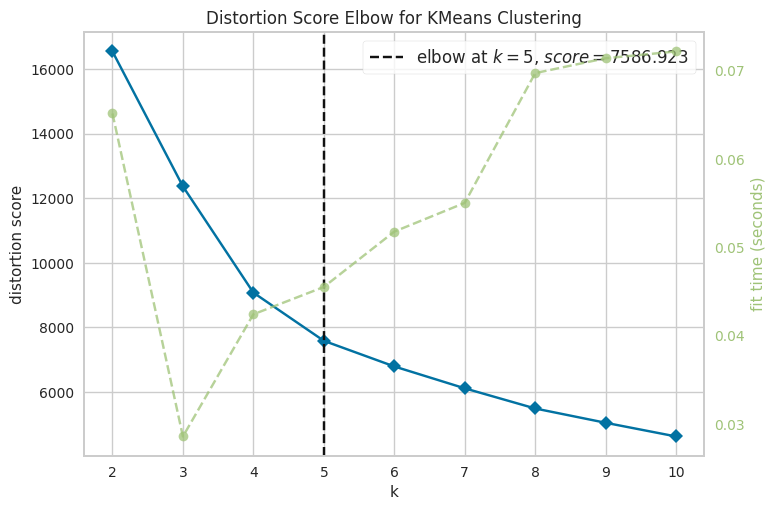

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [43]:
#Using Elbow method to determine the most optimal cluster
model = KMeans()
visualizer = KElbowVisualizer(model, k=10)

visualizer.fit(PCA_ds) # Fit the data to the visualizer
visualizer.show() 

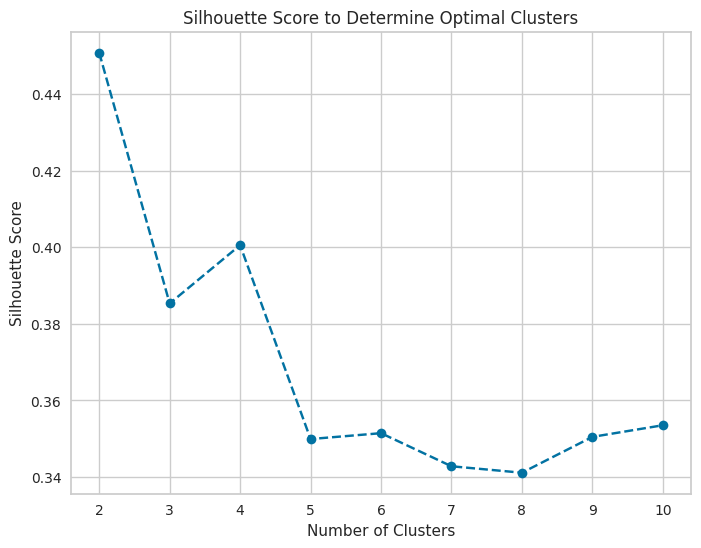

In [44]:
#Using Silhoutte score to find the most optimal clusters
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Run K-Means for cluster numbers from 2 to 10 and calculate silhouette score
for i in range(2, 11):  # Silhouette score cannot be calculated for 1 cluster
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(PCA_ds)  
    score = silhouette_score(PCA_ds, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores to find the optimal cluster number
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score to Determine Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Clustering and Model Interpretation

**Observation**: Based on the above two charts the most optimal cluster numbers seems to be 2, 4 and 5. We'll analyse all three models to get an idea of how these clusters can help marketing teams to target specific customer segments

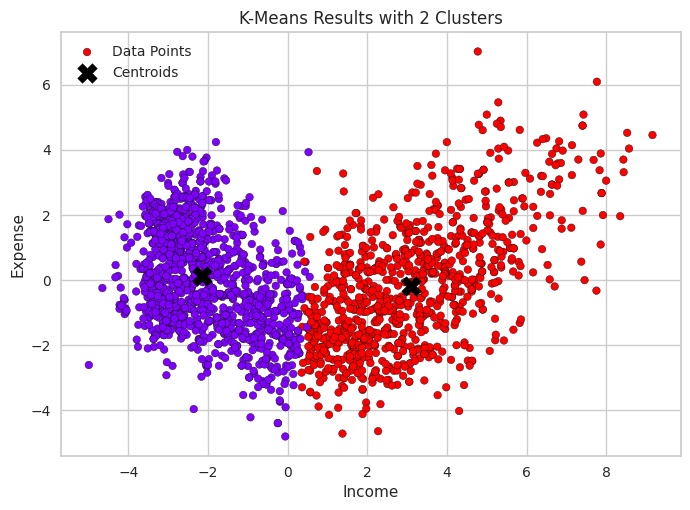

In [45]:

kmeans2 = KMeans(n_clusters=2, random_state=42)
kmeans2.fit(PCA_ds)

#Get cluster labels
labels2 = kmeans2.labels_

# Add cluster labels to the original data
df['Cluster'] = kmeans2.labels_

plt.scatter(PCA_ds.iloc[:, 0], PCA_ds.iloc[:, 1], c=labels2, cmap='rainbow', s=30, label='Data Points',edgecolor='k')

# Plot cluster centroids
centroids2 = kmeans2.cluster_centers_
plt.scatter(centroids2[:, 0], centroids2[:, 1], c='black', s=200, marker='X', label='Centroids')

plt.title("K-Means Results with 2 Clusters")
plt.xlabel('Income')
plt.ylabel('Expense')
plt.grid(True)
plt.legend()
plt.show()

**Observation**: The 2 cluster KMeans gives us a clearly defined chart separated by Income :

**Basically dividing the customers in 2 clusters with low and high income**

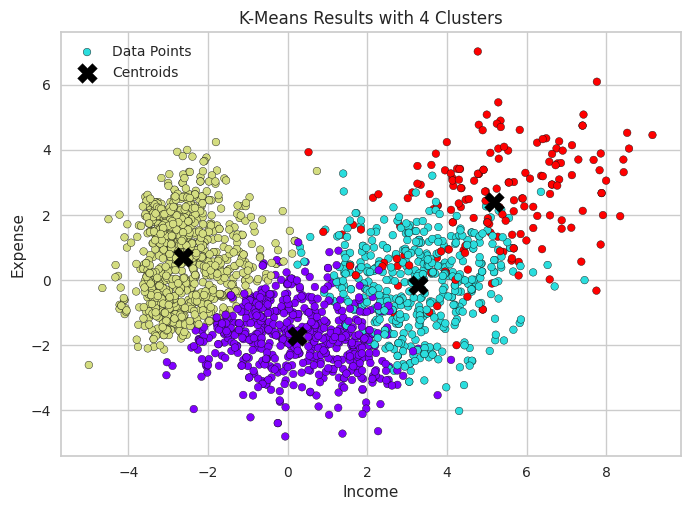

In [46]:

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(PCA_ds)

#Get cluster labels
labels = kmeans.labels_

# Add cluster labels to the original data
df['Cluster'] = kmeans.labels_

plt.scatter(PCA_ds.iloc[:, 0], PCA_ds.iloc[:, 1], c=labels, cmap='rainbow', s=30, label='Data Points',edgecolor='k')

# Plot cluster centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroids')

plt.title("K-Means Results with 4 Clusters")
plt.xlabel('Income')
plt.ylabel('Expense')
plt.grid(True)
plt.legend()
plt.show()

**Observation**: The 4 cluster KMeans gave us 4 distinct clusters - However, there appears to be some overlap between the clusters. Despite this, it provides flexibility in understanding customer expenses with respect to their Income.

* Cluster 1 with 🟡 datapoints : segments customers with low Income and low/high Expense
* Cluster 2 with 🟣 datapoints : segments customers with low/high Income and low Expense
* Cluster 3 with 🔵 datapoints : segments customers with high Income with low/high Expense
* Cluster 4 with 🔴 datapoints : segments customers with high Income and high Expense


**To target specific customer segments we can map the demographic of each customer(based on above EDA) and create our marketing strategies accordingly.**




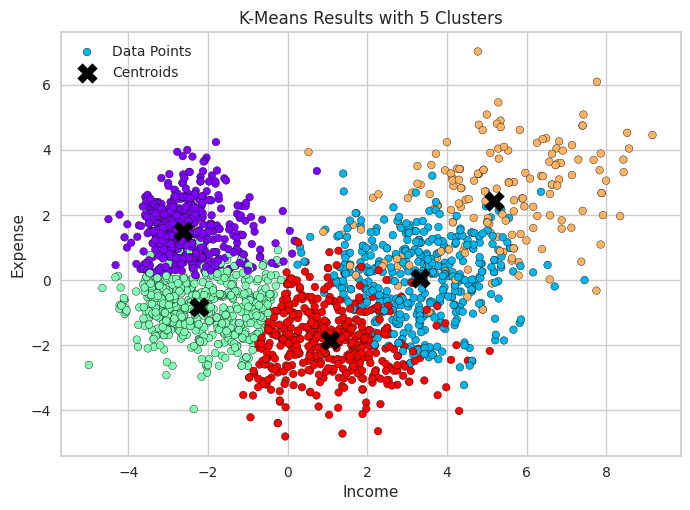

In [47]:

kmeans5 = KMeans(n_clusters=5, random_state=42)
kmeans5.fit(PCA_ds)

#Get cluster labels
labels5 = kmeans5.labels_

# Add cluster labels to the original data
df['Cluster'] = kmeans5.labels_

plt.scatter(PCA_ds.iloc[:, 0], PCA_ds.iloc[:, 1], c=labels5, cmap='rainbow', s=30, label='Data Points',edgecolor='k')

# Plot cluster centroids
centroids5 = kmeans5.cluster_centers_
plt.scatter(centroids5[:, 0], centroids5[:, 1], c='black', s=200, marker='X', label='Centroids')

plt.title("K-Means Results with 5 Clusters")
plt.xlabel('Income')
plt.ylabel('Expense')
plt.grid(True)
plt.legend()
plt.show()

**Observation**: The 5 cluster KMeans gave us 5 distinct clusters - Below is how we can define each customer segment:

* Cluster 1 with 🟣 datapoints : segments customers with low Income and high Expense
* Cluster 2 with 🟢 datapoints : segments customers with low Income and low Expense
* Cluster 3 with 🔴 datapoints : segments customers with high Income and low Expense
* Cluster 4 with 🔵 datapoints : segments customers with high income and high Expense
* Cluster 5 with 🟡 datapoints : segments customers with high income and very high Expense


**In this case Cluster 2, with low income and low expense, is of least interest to us...and we should aggresively target customers from 4 and 5**




# Model Evaluation

Silhouette Score with 2 clusters: 0.4507556286095337
Davies-Bouldin Score with 2 clusters: 0.9498621468788114
Calinski-Harabasz Index with 2 clusters: 2032.8605781658598


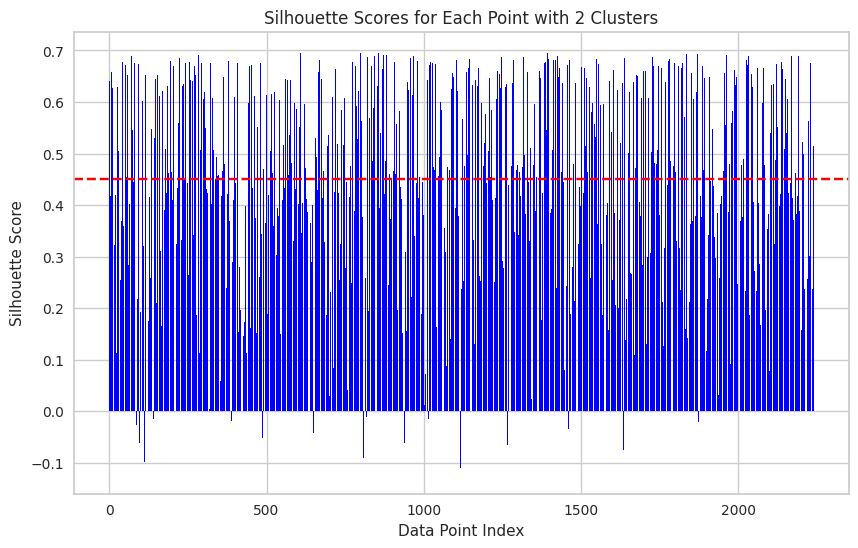

In [48]:
# Silhouette Score for 2 clusters
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(PCA_ds, kmeans2.labels_)
print(f"Silhouette Score with 2 clusters: {sil_score}")

# Davies-Bouldin Score
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(PCA_ds, kmeans2.labels_)
print(f"Davies-Bouldin Score with 2 clusters: {db_score}")

# Calinski-Harabasz Index
from sklearn.metrics import calinski_harabasz_score
ch_score = calinski_harabasz_score(PCA_ds, kmeans2.labels_)
print(f"Calinski-Harabasz Index with 2 clusters: {ch_score}")

# Plot silhouette scores
from sklearn.metrics import silhouette_samples
sample_silhouette_values = silhouette_samples(PCA_ds, kmeans2.labels_)

plt.figure(figsize=(10, 6))
plt.bar(range(len(PCA_ds)), sample_silhouette_values, color='blue')
plt.axhline(y=sil_score, color='red', linestyle='--')
plt.title("Silhouette Scores for Each Point with 2 Clusters")
plt.xlabel("Data Point Index")
plt.ylabel("Silhouette Score")
plt.show()

Silhouette Score with 4 clusters: 0.4005304452165488
Davies-Bouldin Score with 4 clusters: 0.9226039483240672
Calinski-Harabasz Index with 4 clusters: 1847.5870585187613


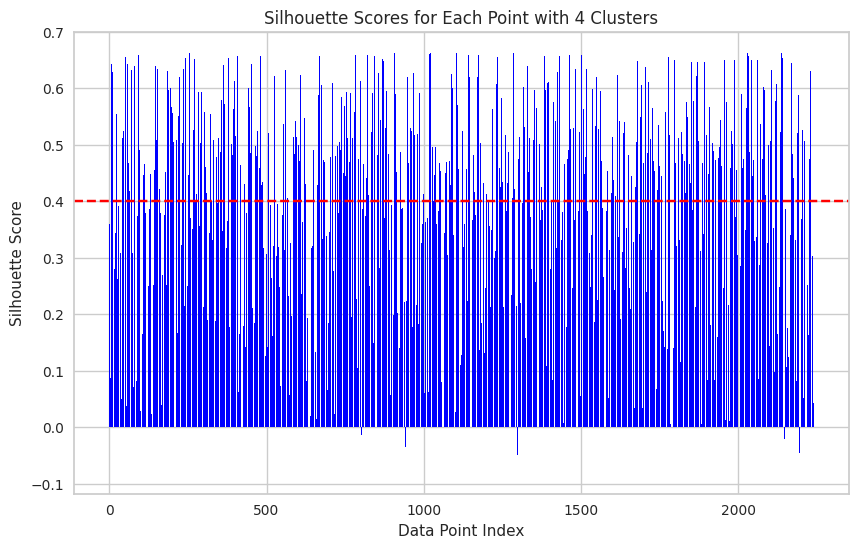

In [49]:
# Silhouette Score for 4 clusters
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(PCA_ds, kmeans.labels_)
print(f"Silhouette Score with 4 clusters: {sil_score}")

# Davies-Bouldin Score
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(PCA_ds, kmeans.labels_)
print(f"Davies-Bouldin Score with 4 clusters: {db_score}")

# Calinski-Harabasz Index
from sklearn.metrics import calinski_harabasz_score
ch_score = calinski_harabasz_score(PCA_ds, kmeans.labels_)
print(f"Calinski-Harabasz Index with 4 clusters: {ch_score}")

# Plot silhouette scores
from sklearn.metrics import silhouette_samples
sample_silhouette_values = silhouette_samples(PCA_ds, kmeans.labels_)

plt.figure(figsize=(10, 6))
plt.bar(range(len(PCA_ds)), sample_silhouette_values, color='blue')
plt.axhline(y=sil_score, color='red', linestyle='--')
plt.title("Silhouette Scores for Each Point with 4 Clusters")
plt.xlabel("Data Point Index")
plt.ylabel("Silhouette Score")
plt.show()

Silhouette Score with 5 clusters: 0.3499303147087333
Davies-Bouldin Score with 5 clusters: 0.9732948970680659
Calinski-Harabasz Index with 5 clusters: 1767.6123597304777


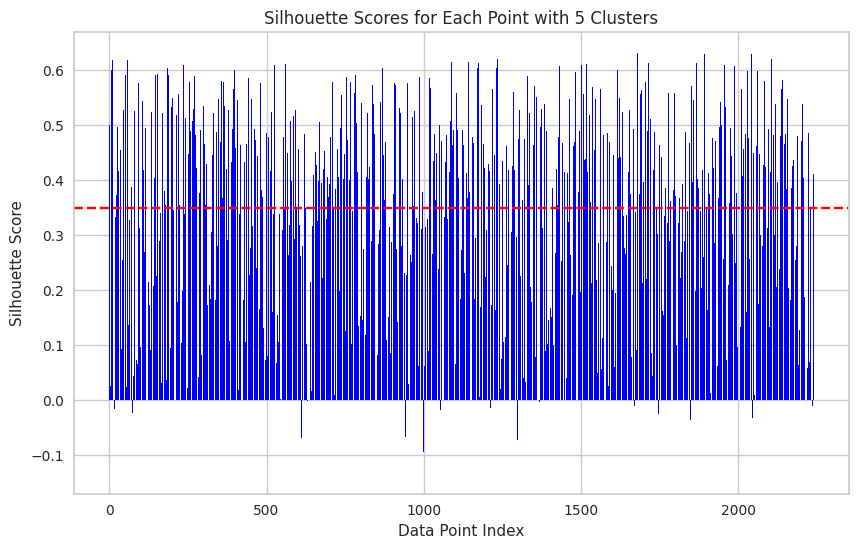

In [50]:
# Silhouette Score for 5 clusters
from sklearn.metrics import silhouette_score
sil_score5 = silhouette_score(PCA_ds, kmeans5.labels_)
print(f"Silhouette Score with 5 clusters: {sil_score5}")

# Davies-Bouldin Score
from sklearn.metrics import davies_bouldin_score
db_score5 = davies_bouldin_score(PCA_ds, kmeans5.labels_)
print(f"Davies-Bouldin Score with 5 clusters: {db_score5}")

# Calinski-Harabasz Index
from sklearn.metrics import calinski_harabasz_score
ch_score5 = calinski_harabasz_score(PCA_ds, kmeans5.labels_)
print(f"Calinski-Harabasz Index with 5 clusters: {ch_score5}")

# Plot silhouette scores
from sklearn.metrics import silhouette_samples
sample_silhouette_values = silhouette_samples(PCA_ds, kmeans5.labels_)

plt.figure(figsize=(10, 6))
plt.bar(range(len(PCA_ds)), sample_silhouette_values, color='blue')
plt.axhline(y=sil_score5, color='red', linestyle='--')
plt.title("Silhouette Scores for Each Point with 5 Clusters")
plt.xlabel("Data Point Index")
plt.ylabel("Silhouette Score")
plt.show()

**Observation**: Model with 2 clusters has better model metrices as compared to models with clusters 4 and 5

# Concusion

📊 In this notebook, we conducted a thorogh EDA to find out uncover different cutomer profiles based on their Marital Status, Age Group, Education and Income.

🛍 We also examined the shopping habbits for customer segment - providing valueable insights which can be useful for creating customized promotional strategies.

🖥 Additionally, we developed three KMeans clustering models with 2, 4, and 5 clusters. For each model, we analyzed how marketing teams can effectively approach their respective customer groups.


‣If you found this notebook helpful, don't forget to upvote! 👍

‣Have any questions? Drop them in the comments below! 💬